# Strategy Research Notebook

目標：
1. 在 notebook 直接修改策略邏輯
2. 使用正式資料抓取模組
3. 使用正式回測與 metrics 模組
4. 在 notebook 內直接做參數最佳化
5. 找到可行策略後，再搬回 `src/strategies/`

In [1]:
from pathlib import Path
import sys

# 找到專案根目錄（假設 notebook 放在 notebooks/ 底下）
PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = C:\Users\USER\Desktop\Quant_project


## 1. 匯入基本套件與專案模組

這裡只匯入：
- 基本資料分析套件
- 專案內正式模組

Notebook 不重寫一套系統，只負責研究。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.utils.config import load_yaml
from src.data.fetchers import fetch_yfinance_data
from src.backtest.engine import run_backtest
from src.backtest.metrics import calculate_full_metrics

## 2. 讀取設定檔

研究 notebook 與正式專案共用同一份設定邏輯。
這樣研究完成後，搬回 `src/` 會很自然。

In [3]:
config = load_yaml(PROJECT_ROOT / "config" / "strategy.yaml")

symbol = config["data"]["symbol"]
start = config["data"]["start"]
end = config["data"]["end"]
interval = config["data"]["interval"]
fee_rate = config["backtest"]["fee_rate"]

print(config)

{'strategy': {'name': 'ma_cross', 'short_window': 5, 'long_window': 20}, 'data': {'symbol': '0050.TW', 'start': '2016-01-01', 'end': '2025-12-31', 'interval': '1D'}, 'backtest': {'fee_rate': 0.001}}


## 3. 抓取資料

先使用正式資料抓取模組。
研究時也應該沿用正式資料流程，不要 notebook 自己重寫資料抓取。

In [5]:
#抓資料
df = fetch_yfinance_data(
    symbol=symbol,
    start=start,
    end=end,
    interval=interval
)

print(df.shape)
df.head()

(2430, 8)


,symbol,datetime,open,high,low,close,volume,adj_close
0,0050.TW,2016-01-04,15.2000,15.2375,14.7625,14.8875,67712252,10.816449
1,0050.TW,2016-01-05,14.8750,14.9375,14.7125,14.7625,87135876,10.725631
2,0050.TW,2016-01-06,14.7625,14.7625,14.4750,14.6125,115758200,10.616649
3,0050.TW,2016-01-07,14.5750,14.5750,14.1750,14.3375,159849204,10.416850
4,0050.TW,2016-01-08,14.2500,14.4250,14.2125,14.3625,101802936,10.435015


## 4. 策略研發處

這裡直接在 notebook 改策略，不用先回 `src/strategies/`。
等研究確認有價值，再正式搬回去。

In [13]:
import numpy as np
import pandas as pd


def compute_cci(data: pd.DataFrame, window: int = 20) -> pd.Series:
    tp = (data["high"] + data["low"] + data["close"]) / 3
    sma = tp.rolling(window).mean()
    mad = tp.rolling(window).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
    cci = (tp - sma) / (0.015 * mad)
    return cci


def compute_atr(data: pd.DataFrame, window: int = 14) -> pd.Series:
    prev_close = data["close"].shift(1)

    tr1 = data["high"] - data["low"]
    tr2 = (data["high"] - prev_close).abs()
    tr3 = (data["low"] - prev_close).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window).mean()
    return atr


def research_strategy(
    data: pd.DataFrame,
    ma_short_window: int = 5,
    ma_long_window: int = 20,
    cci_window: int = 50,
    cci_entry_threshold: float = 20,
    cci_exit_threshold: float = 10,
    vol_now_window: int = 15,
    atr_window: int = 14,
    atr_mult: float = 2.0,
    use_short: bool = True,
) -> pd.DataFrame:
    """
    策略端負責產生：
    - entry_long / exit_long
    - entry_short / exit_short
    - long_stop_price / short_stop_price

    回測器只負責讀這些欄位執行。
    """

    required_cols = ["datetime", "open", "high", "low", "close", "volume"]
    missing_cols = [col for col in required_cols if col not in data.columns]
    if missing_cols:
        raise ValueError(f"資料缺少必要欄位: {missing_cols}")

    df = data.copy().sort_values("datetime").reset_index(drop=True)

    # ===== 指標 =====
    df["ma_short"] = df["close"].rolling(ma_short_window).mean()
    df["ma_long"] = df["close"].rolling(ma_long_window).mean()

    df["vol_ma_now"] = df["volume"].rolling(vol_now_window).mean()

    df["cci"] = compute_cci(df, window=cci_window)
    df["cci_prev"] = df["cci"].shift(1)

    df["atr"] = compute_atr(df, window=atr_window)

    # ===== 進出場條件 =====
    df["entry_long"] = (
        (df["cci"] > cci_entry_threshold) &
        (df["ma_short"] > df["ma_long"]) &
        (df["volume"] > df["vol_ma_now"])
    )

    df["exit_long"] = (
        (df["cci_prev"] >= cci_exit_threshold) &
        (df["cci"] < cci_exit_threshold)
    )

    if use_short:
        df["entry_short"] = (
            (df["cci"] < -cci_entry_threshold) &
            (df["ma_short"] < df["ma_long"]) &
            (df["volume"] > df["vol_ma_now"])
        )

        df["exit_short"] = (
            (df["cci_prev"] <= -cci_exit_threshold) &
            (df["cci"] > -cci_exit_threshold)
        )
    else:
        df["entry_short"] = False
        df["exit_short"] = False

    # ===== 停損欄位 =====
    df["long_stop_price"] = np.nan
    df["short_stop_price"] = np.nan

    current_pos = 0
    highest_since_entry = np.nan
    lowest_since_entry = np.nan

    for i in range(len(df)):
        row = df.loc[i]

        # 空手 -> 看進場
        if current_pos == 0:
            if bool(row["entry_long"]):
                current_pos = 1
                highest_since_entry = row["high"]
                lowest_since_entry = np.nan

                if pd.notna(row["atr"]):
                    df.loc[i, "long_stop_price"] = highest_since_entry - atr_mult * row["atr"]

            elif bool(row["entry_short"]):
                current_pos = -1
                lowest_since_entry = row["low"]
                highest_since_entry = np.nan

                if pd.notna(row["atr"]):
                    df.loc[i, "short_stop_price"] = lowest_since_entry + atr_mult * row["atr"]

        # 持有多單
        elif current_pos == 1:
            highest_since_entry = max(highest_since_entry, row["high"])

            if pd.notna(row["atr"]):
                df.loc[i, "long_stop_price"] = highest_since_entry - atr_mult * row["atr"]

            stop_hit = (
                pd.notna(df.loc[i, "long_stop_price"]) and
                row["low"] <= df.loc[i, "long_stop_price"]
            )

            if bool(row["exit_long"]) or stop_hit:
                current_pos = 0
                highest_since_entry = np.nan
                df.loc[i, "long_stop_price"] = np.nan

        # 持有空單
        elif current_pos == -1:
            lowest_since_entry = min(lowest_since_entry, row["low"])

            if pd.notna(row["atr"]):
                df.loc[i, "short_stop_price"] = lowest_since_entry + atr_mult * row["atr"]

            stop_hit = (
                pd.notna(df.loc[i, "short_stop_price"]) and
                row["high"] >= df.loc[i, "short_stop_price"]
            )

            if bool(row["exit_short"]) or stop_hit:
                current_pos = 0
                lowest_since_entry = np.nan
                df.loc[i, "short_stop_price"] = np.nan

    return df

## 5. 單次測試策略

直接測試策略績效

========== Trading Record ==========
   entry_time  exit_time  entry_price  exit_price    return  hold_days
0  2016-03-30 2016-04-28    16.174999   15.600000 -0.021073         29
1  2016-05-30 2016-09-12    15.787500   17.212500  0.113691        105
2  2016-09-21 2016-11-04    17.812500   17.750000 -0.001701         44
3  2016-12-08 2016-12-20    18.225000   17.937500 -0.015389         12
4  2017-01-06 2017-02-08    18.162500   17.937500  0.007938         33
5  2017-02-10 2017-08-16    18.200001   20.250000  0.028510        187
6  2017-08-30 2017-11-15    20.674999   20.825001 -0.015769         77
7  2018-01-05 2018-02-05    20.937500   20.900000  0.012718         31
8  2018-06-06 2018-10-04    20.825001   21.225000 -0.016010        120
9  2019-02-18 2019-05-14    18.912500   19.912500  0.058425         85
10 2019-06-21 2019-06-26    20.212500   20.087500 -0.002236          5
11 2019-06-27 2019-08-02    20.375000   20.237499  0.008806         36
12 2019-09-05 2020-09-23    20.750000   

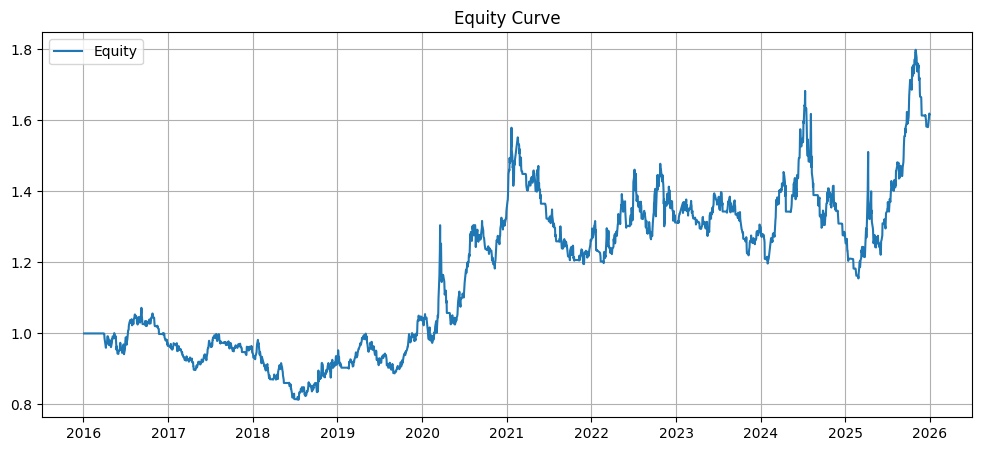

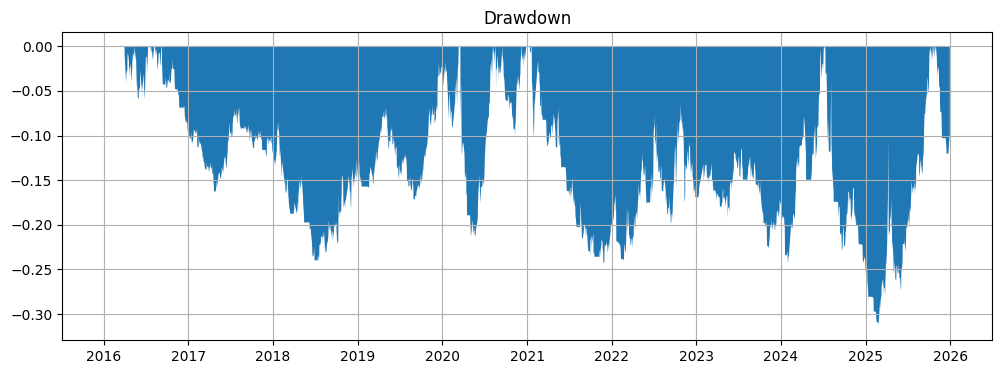

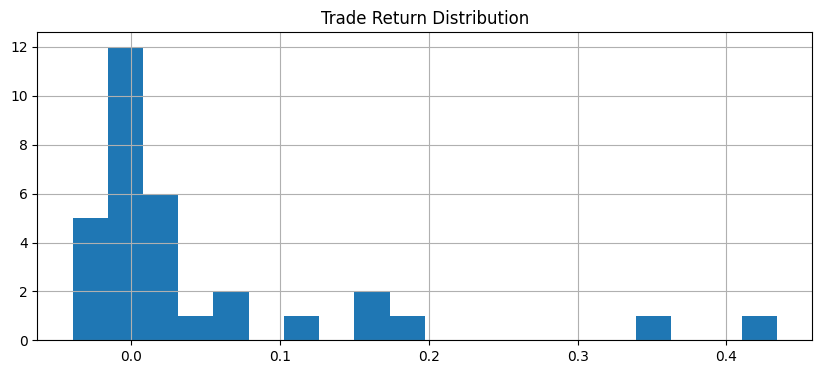

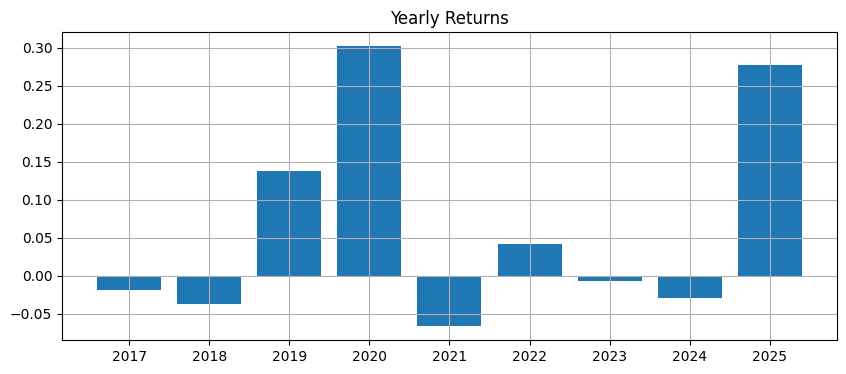

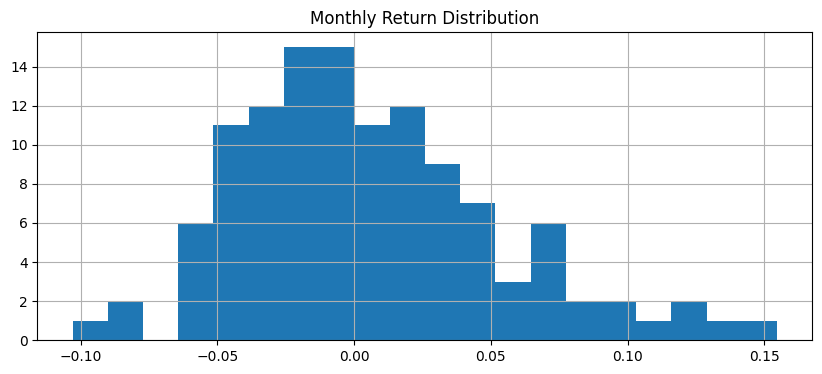

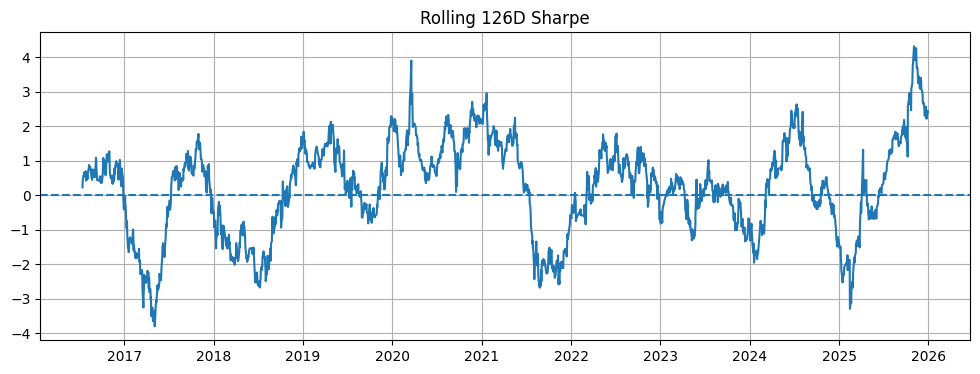

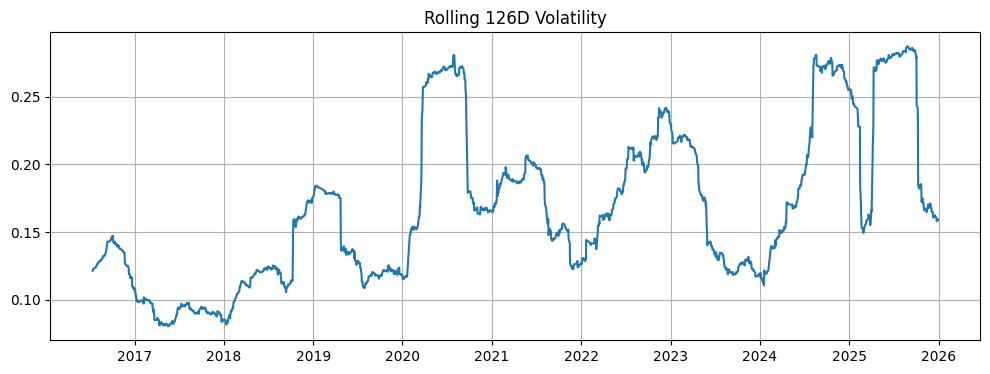

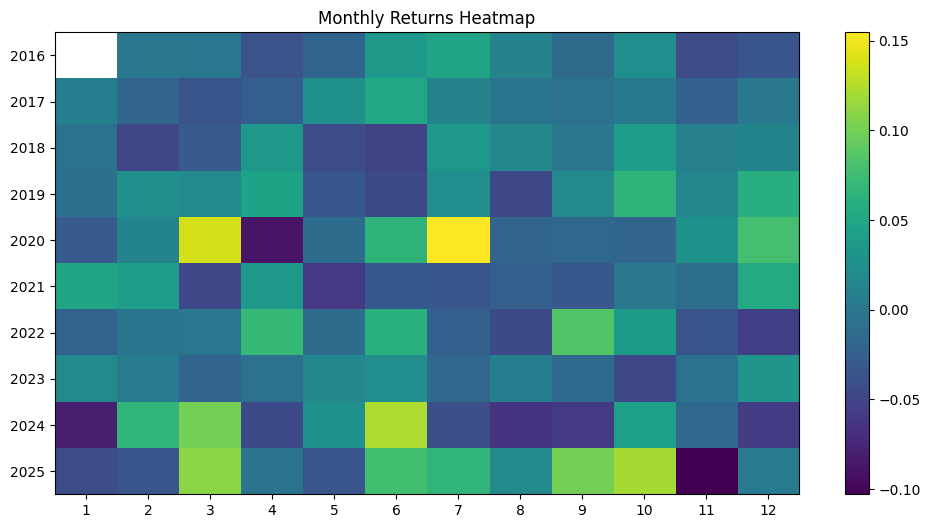

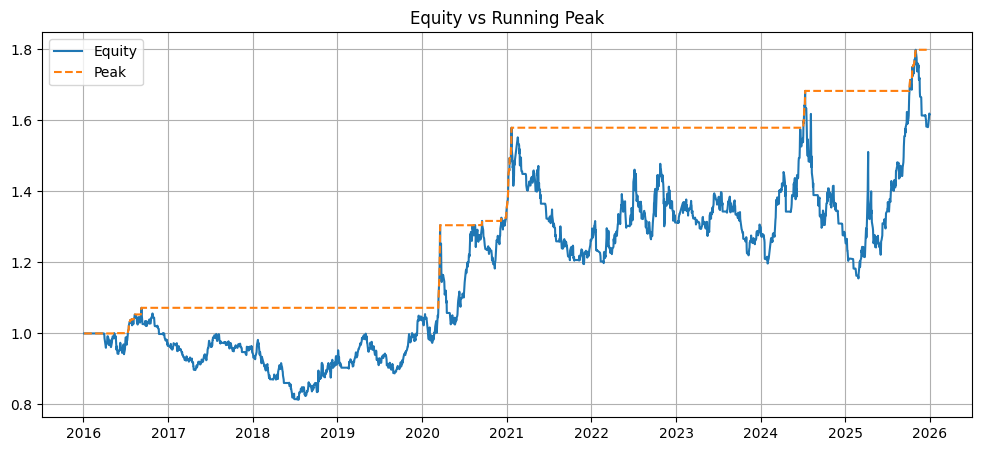

In [14]:
signal_df = research_strategy(
    df,
    ma_short_window=5,
    ma_long_window=20,
    cci_window=50,
    cci_entry_threshold=20,
    cci_exit_threshold=10,
    vol_now_window=15,
    atr_window=14,
    atr_mult=2.0,
    use_short=True,
)

backtest_df = run_backtest(
    signal_df,
    fee_rate=0.001,
    allow_short=True,
)

metrics, trade_df, worst_dd_df = calculate_full_metrics(
    backtest_df,
    annual_trading_days=252,
    rolling_window=126,
    verbose=True,
    show_plots=True,
)

## 6. 查看交易紀錄與最差回撤區間

In [8]:
print(trade_df.head(10))
print(worst_dd_df.head(10))

  entry_time  exit_time  entry_price  exit_price    return  hold_days
0 2016-03-30 2016-04-01    16.174999   15.975000 -0.001772          2
1 2016-05-30 2016-06-13    15.787500   15.937500  0.032221         14
2 2016-06-15 2016-07-06    16.062500   16.225000  0.027765         21
3 2016-07-11 2016-07-25    16.750000   17.250000  0.033294         14
4 2016-07-29 2016-08-19    17.137501   17.299999  0.018674         21
5 2016-09-07 2016-09-09    17.962500   17.600000 -0.004476          2
6 2016-09-21 2016-10-31    17.812500   18.150000  0.017928         40
7 2016-11-02 2016-11-04    17.937500   17.750000 -0.008658          2
8 2016-12-08 2016-12-16    18.225000   18.075001  0.000370          8
9 2017-01-06 2017-01-16    18.162500   18.000000 -0.001688         10
       start        end  min_drawdown  duration
0 2021-01-22 2025-09-23     -0.283860      1133
1 2016-08-11 2020-03-19     -0.271468       876
2 2020-03-20 2020-12-07     -0.227615       179
3 2025-11-03 2025-12-30     -0.121151 

## 7. 查看評價

In [9]:
from src.backtest.diagnosis import diagnose_performance
diagnosis_df, avg_score, overall_comment = diagnose_performance(
    metrics,
    verbose=True
)   


========== Strategy Diagnosis ==========
[Sharpe] 0.267 | 評價：普通 | Sharpe 偏弱，風險調整後績效有限。
[Sortino] 0.301 | 評價：普通 | Sortino 普通，對壞波動的補償不算強。
[Calmar] 0.108 | 評價：差 | Calmar 偏弱，報酬相對最大回撤不夠漂亮。
[MDD] -28.39% | 評價：普通 | 最大回撤偏大，需搭配較高報酬才合理。
[Profit Factor] 6.483 | 評價：優秀 | 獲利品質很強，交易結構相對健康。
[Expectancy] 2.06% | 評價：優秀 | 每筆交易期望值很強，出手機會品質佳。
[Stability] 0.397 | 評價：普通 | 資金曲線穩定度普通。
[CAGR] 3.06% | 評價：普通 | 年化報酬偏低，但仍需搭配風險指標一起判讀。
[Payoff Ratio] 7.184 | 評價：優秀 | 賺賠結構很強，屬於明顯賺大於賠的型態。
[Total Return] 33.77% | 評價：描述 | 用來看策略從頭到尾總共賺了多少或虧了多少，但會受回測期間長短影響。
[Volatility] 16.16% | 評價：描述 | 數值越大代表績效起伏越大，但不能單獨判斷好壞，需搭配 Sharpe 或 Calmar 一起看。
[Win Rate] 47.44% | 評價：描述 | 反映策略命中率，但高勝率不一定代表策略好，仍需搭配賺賠比與 Profit Factor 一起判讀。
[Skewness] 0.124 | 評價：描述 | 正偏通常代表偶爾有較大的獲利，負偏則表示較容易出現大虧損。
[Kurtosis] 16.509 | 評價：描述 | 數值越高通常代表肥尾越明顯，也就是極端波動發生的機率較高。
[Tail Ratio] 1.002 | 評價：描述 | 大於 1 通常表示正向尾部比負向尾部更強，代表大賺的潛力相對較高。
[VaR 95%] -1.47% | 評價：描述 | 可理解為一般情況下最差 5% 時的損失邊界，但無法描述更極端情況的平均損失。
[CVaR 95%] -2.46% | 評價：描述 | 比 VaR 更能反映真正壞情況下的尾部風險。
[Exposure] 65.43% | 評價：

In [ ]:
diagnosis_df[["Metric", "Grade", "Comment"]]

In [ ]:
diagnosis_df[diagnosis_df["Grade"].isin(["差", "需留意"])]

## 參數最佳化（Notebook 版）

這裡直接在 notebook 內做 grid search。
研究時可以很快改策略、改範圍、改指標。

In [16]:
#切分 Train / Test
split_date = "2023-01-01"   # 可以自己改

df["datetime"] = pd.to_datetime(df["datetime"])

train_df = df[df["datetime"] < split_date].copy()
test_df = df[df["datetime"] >= split_date].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (1707, 8)
Test shape : (723, 8)


In [17]:
# =========================
# CCI 進出場參數範圍設定
# =========================
cci_entry_range = range(10, 41, 5)   # 10, 15, 20, 25, 30, 35, 40
cci_exit_range = range(0, 21, 5)     # 0, 5, 10, 15, 20

# =========================
# 固定其他策略參數
# =========================
ma_short_window = 5
ma_long_window = 20
cci_window = 50
vol_now_window = 15
atr_window = 14
atr_mult = 2.0
use_short = True

# =========================
# Train Set 參數最佳化
# =========================
results = []

for cci_entry_threshold in cci_entry_range:
    for cci_exit_threshold in cci_exit_range:

        # 一般會希望 exit threshold 小於 entry threshold
        if cci_exit_threshold >= cci_entry_threshold:
            continue

        signal_df_tmp = research_strategy(
            train_df,
            ma_short_window=ma_short_window,
            ma_long_window=ma_long_window,
            cci_window=cci_window,
            cci_entry_threshold=cci_entry_threshold,
            cci_exit_threshold=cci_exit_threshold,
            vol_now_window=vol_now_window,
            atr_window=atr_window,
            atr_mult=atr_mult,
            use_short=use_short,
        )

        backtest_df_tmp = run_backtest(
            signal_df_tmp,
            fee_rate=fee_rate,
            allow_short=use_short,
        )

        metrics_tmp, _, _ = calculate_full_metrics(
            backtest_df_tmp,
            annual_trading_days=252,
            rolling_window=126,
            verbose=False,
            show_plots=False,
        )

        results.append({
            "cci_entry_threshold": cci_entry_threshold,
            "cci_exit_threshold": cci_exit_threshold,
            "total_return": metrics_tmp["total_return"],
            "cagr": metrics_tmp["cagr"],
            "sharpe": metrics_tmp["sharpe"],
            "mdd": metrics_tmp["mdd"],
            "win_rate": metrics_tmp["win_rate"],
            "profit_factor": metrics_tmp["profit_factor"],
            "payoff_ratio": metrics_tmp["payoff_ratio"],
            "expectancy": metrics_tmp["expectancy"],
        })

train_result_df = pd.DataFrame(results)
train_result_df = train_result_df.sort_values(
    ["sharpe", "total_return"],
    ascending=False
).reset_index(drop=True)

train_result_df.head(20)

,cci_entry_threshold,cci_exit_threshold,total_return,cagr,sharpe,mdd,win_rate,profit_factor,payoff_ratio,expectancy
0,10,5,0.434362,0.054696,0.405782,-0.256086,0.588235,8.163995,5.714797,0.046165
1,15,5,0.406193,0.051612,0.388226,-0.256086,0.529412,7.663350,6.811866,0.044799
2,20,5,0.402126,0.051162,0.386617,-0.255052,0.578947,9.717885,7.067553,0.044356
3,25,5,0.354008,0.045757,0.355265,-0.255052,0.550000,8.526526,6.976248,0.043058
4,30,5,0.343276,0.044529,0.348417,-0.255052,0.500000,7.431958,7.431958,0.038821
5,15,10,0.316020,0.041373,0.329963,-0.262435,0.578947,11.280938,8.204319,0.041569
6,20,10,0.312213,0.040928,0.328086,-0.243169,0.550000,9.933379,8.127310,0.041679
7,10,0,0.316165,0.041390,0.326240,-0.309845,0.500000,3.745141,3.745141,0.043017
8,20,15,0.301307,0.039646,0.321903,-0.247628,0.640000,10.017518,5.634854,0.034754
9,15,0,0.299788,0.039467,0.315358,-0.309845,0.428571,3.616251,4.821668,0.041884


In [18]:
#拿出最好的
best_row = train_result_df.iloc[0]
display(best_row)

best_entry_threshold = int(best_row["cci_entry_threshold"])
best_exit_threshold = int(best_row["cci_exit_threshold"])

cci_entry_threshold    10.000000
cci_exit_threshold      5.000000
total_return            0.434362
cagr                    0.054696
sharpe                  0.405782
mdd                    -0.256086
win_rate                0.588235
profit_factor           8.163995
payoff_ratio            5.714797
expectancy              0.046165
Name: 0, dtype: float64

========== Trading Record ==========
   entry_time  exit_time  entry_price  exit_price    return  hold_days
0  2016-03-30 2016-09-12    16.174999   17.212500  0.063942        166
1  2016-09-21 2016-11-04    17.812500   17.750000 -0.001701         44
2  2016-12-08 2016-12-20    18.225000   17.937500 -0.015389         12
3  2017-01-06 2017-02-08    18.162500   17.937500  0.007938         33
4  2017-02-10 2017-08-18    18.200001   20.287500  0.032938        189
5  2017-08-30 2017-11-28    20.674999   20.900000 -0.015769         90
6  2018-01-04 2018-02-05    20.875000   20.900000  0.015750         32
7  2018-06-06 2018-10-04    20.825001   21.225000 -0.012978        120
8  2019-02-18 2019-08-02    18.912500   20.237499  0.049825        165
9  2019-09-04 2020-09-23    20.537500   25.737499  0.448908        385
10 2020-10-08 2021-03-09    26.549999   32.837502  0.177957        152
11 2021-03-31 2021-05-05    33.687500   33.937500  0.016052         35
12 2021-06-07 2021-06-09    34.325001   

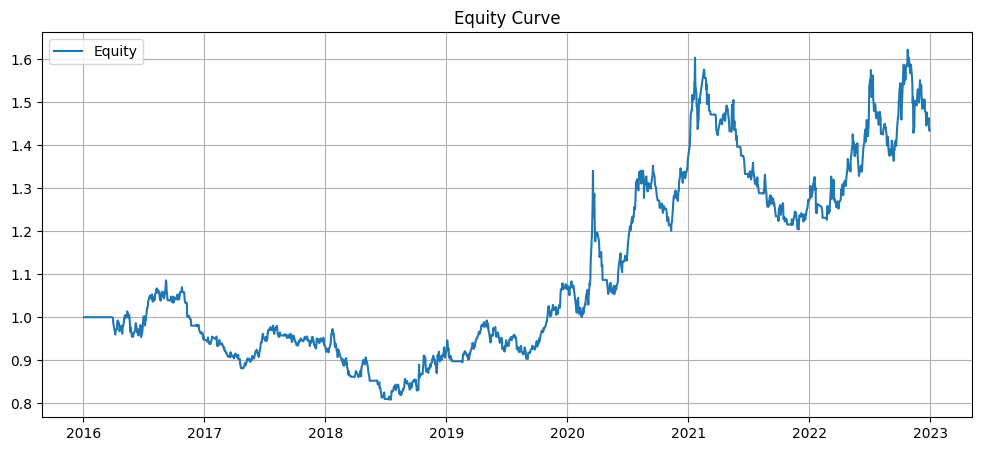

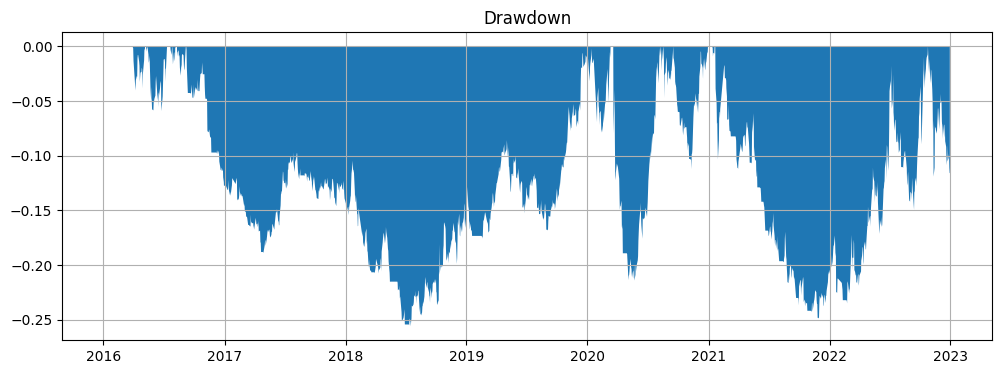

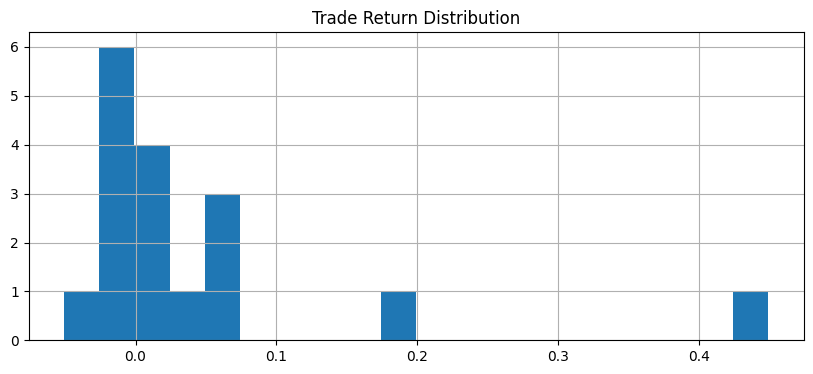

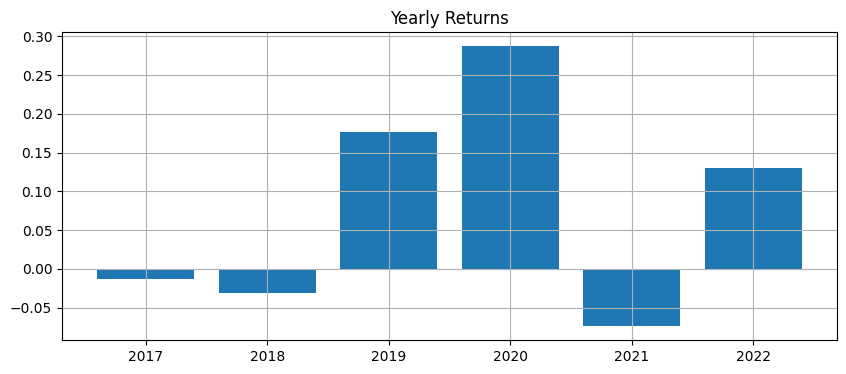

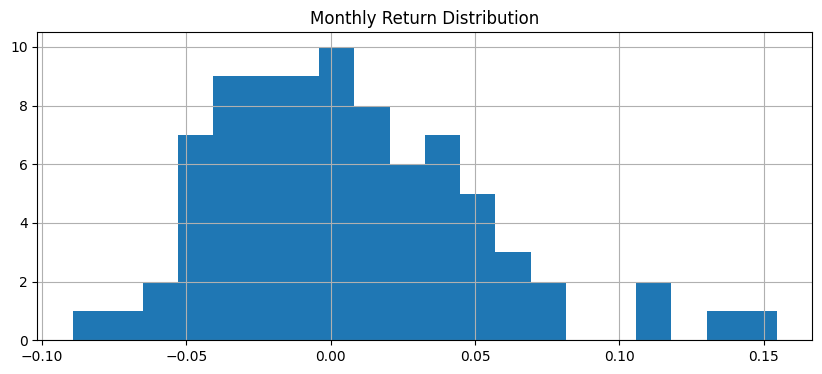

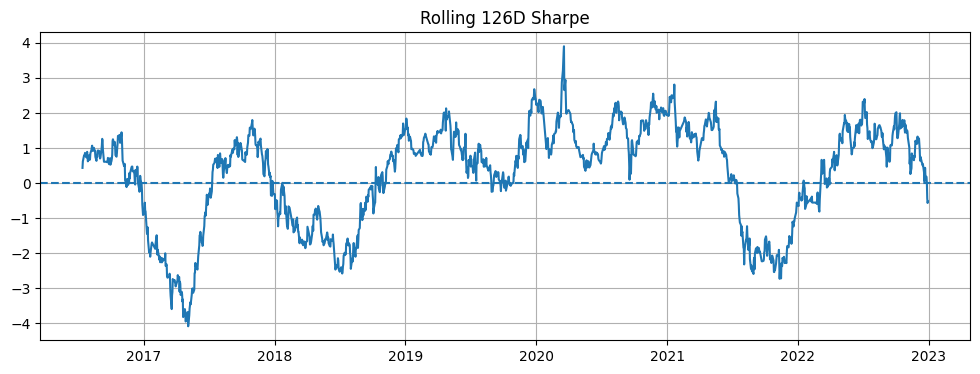

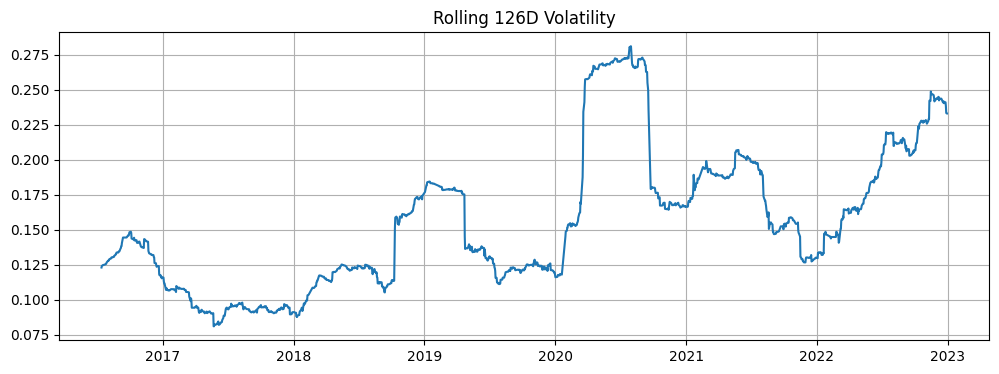

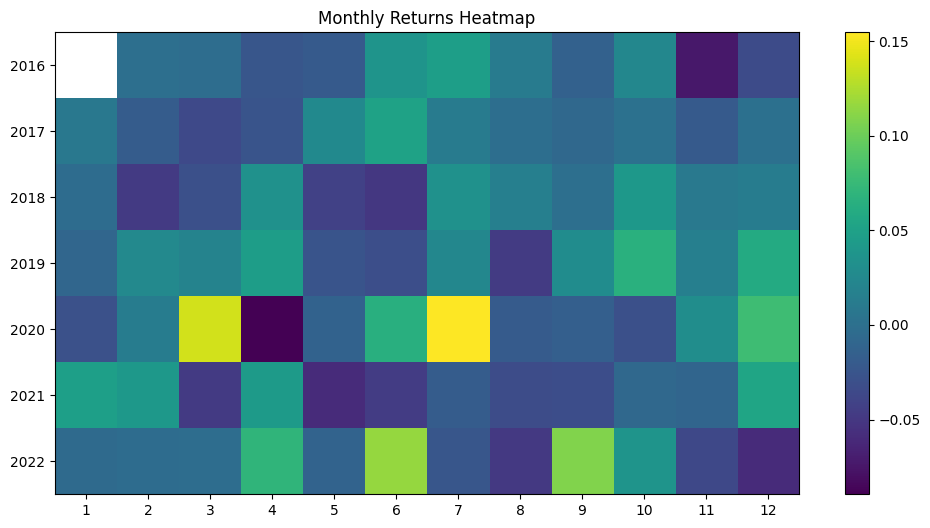

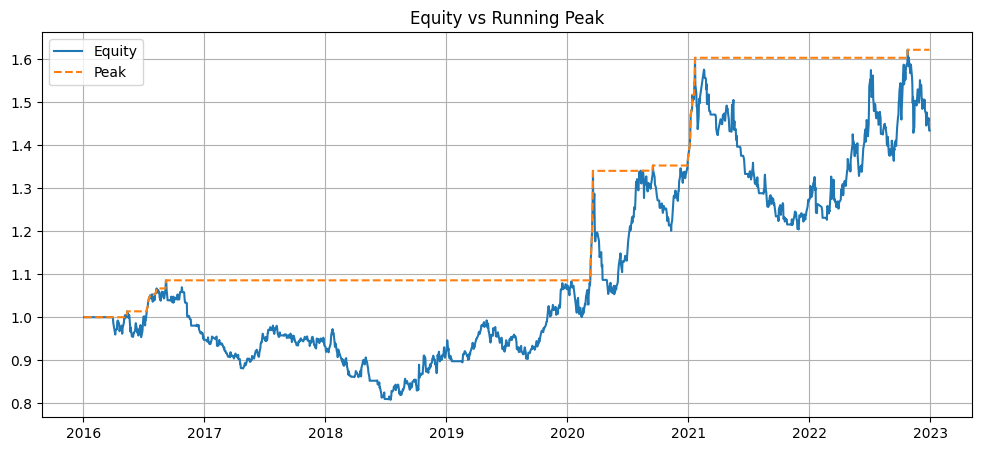

In [19]:
#把最佳化參數放進去跑Train績效結果
best_train_signal_df = research_strategy(
    train_df,
    ma_short_window=ma_short_window,
    ma_long_window=ma_long_window,
    cci_window=cci_window,
    cci_entry_threshold=best_entry_threshold,
    cci_exit_threshold=best_exit_threshold,
    vol_now_window=vol_now_window,
    atr_window=atr_window,
    atr_mult=atr_mult,
    use_short=use_short,
)

best_train_backtest_df = run_backtest(
    best_train_signal_df,
    fee_rate=fee_rate,
    allow_short=use_short,
)

best_train_metrics, best_train_trade_df, best_train_worst_dd_df = calculate_full_metrics(
    best_train_backtest_df,
    annual_trading_days=252,
    rolling_window=126,
    verbose=True,
    show_plots=True,
)

========== Trading Record ==========
  entry_time  exit_time  entry_price  exit_price    return  hold_days
0 2023-03-30 2023-04-13    30.299999   29.875000 -0.006358         14
1 2023-10-12 2023-10-19    31.825001   31.212500 -0.020619          7
2 2023-11-08 2024-01-16    31.799999   32.912498  0.041803         69
3 2024-01-25 2024-04-22    33.912498   37.612499  0.111309         88
4 2024-05-10 2024-11-26    40.412498   47.462502  0.007207        200
5 2024-12-17 2024-12-20    49.275002   48.150002 -0.014685          3
6 2024-12-23 2025-01-15    49.312500   48.525002 -0.009357         23
7 2025-05-13 2025-11-19    44.712502   60.049999  0.350619        190
8 2025-12-11 2025-12-16    63.349998   62.250000 -0.009673          5
9 2025-12-23 2025-12-30    63.700001   65.150002  0.021740          7
========== Performance Summary ==========
total_return        : 27.19%
cagr                : 8.75%
vol                 : 20.03%
sharpe              : 0.518
mdd                 : -29.51%

======

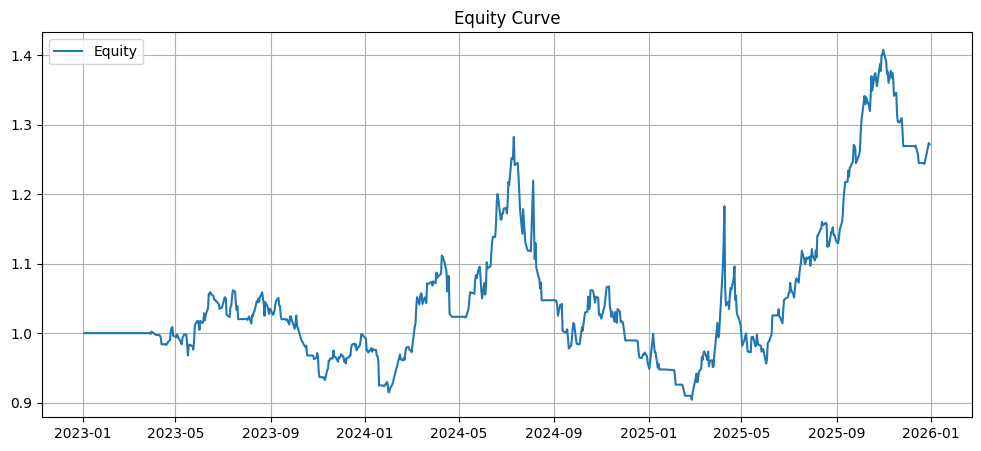

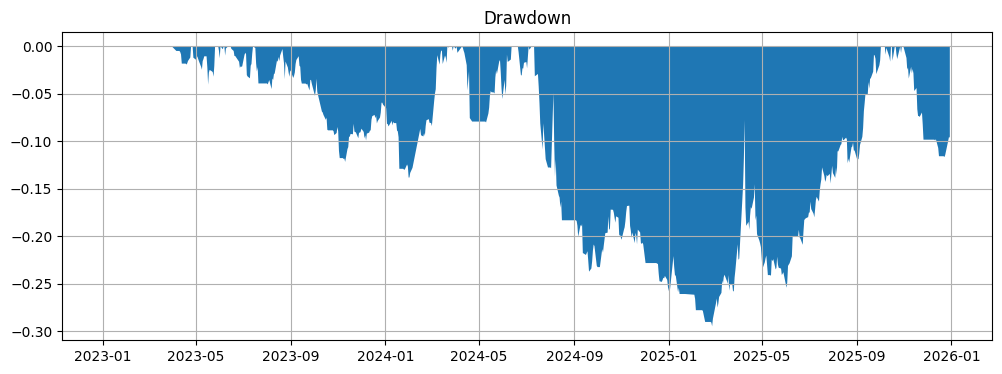

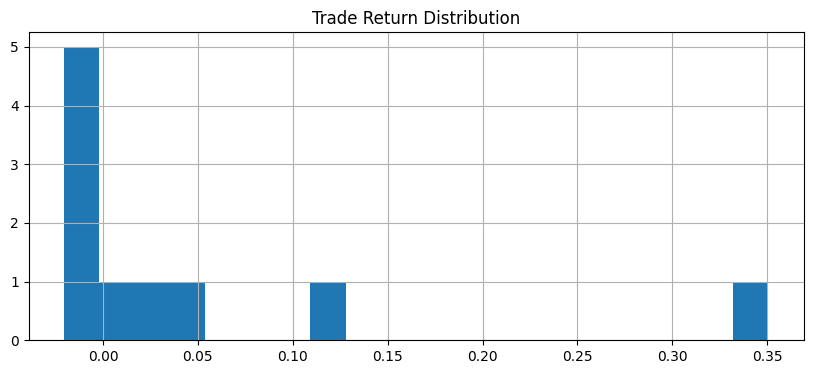

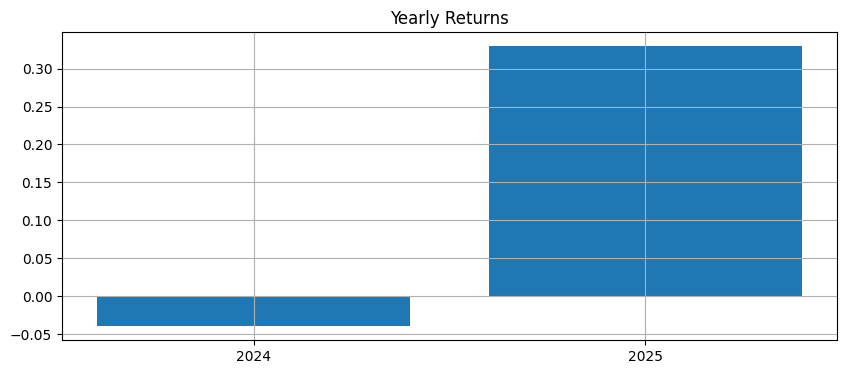

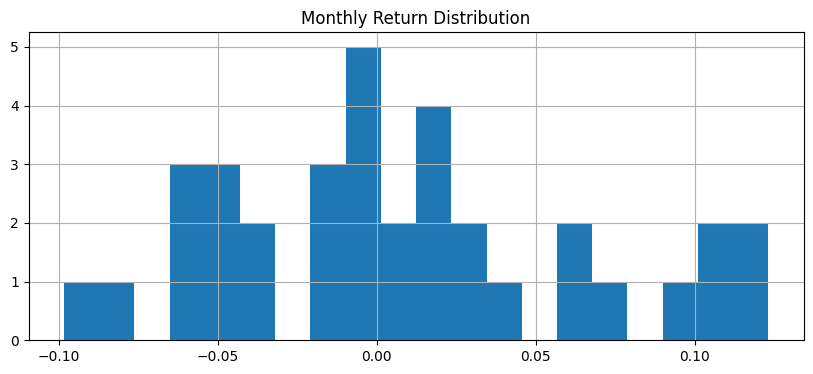

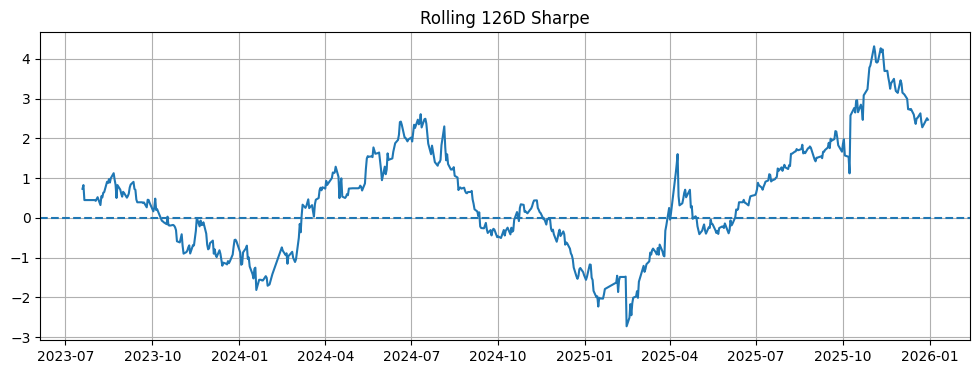

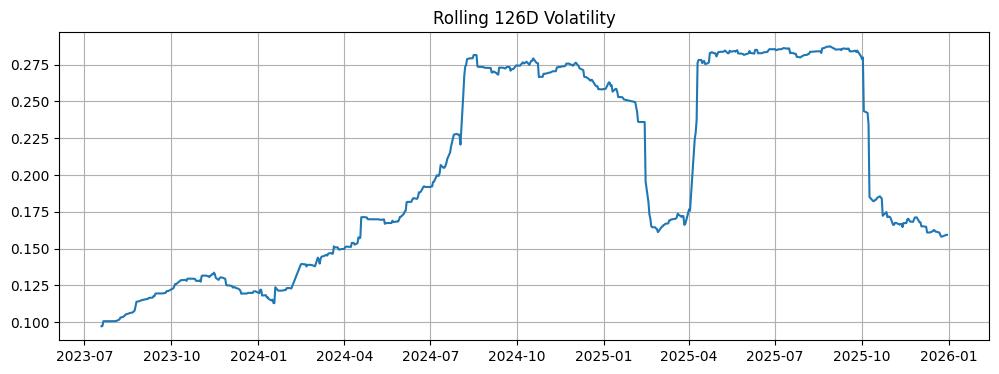

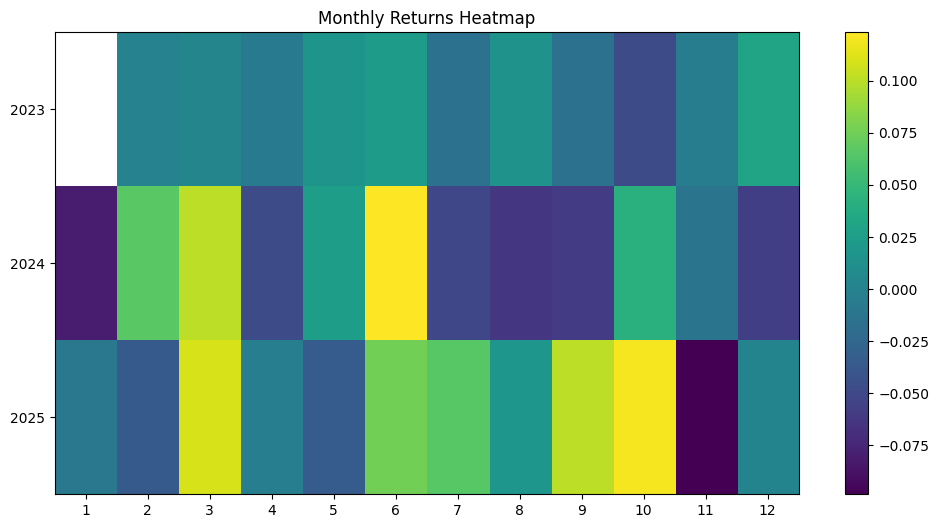

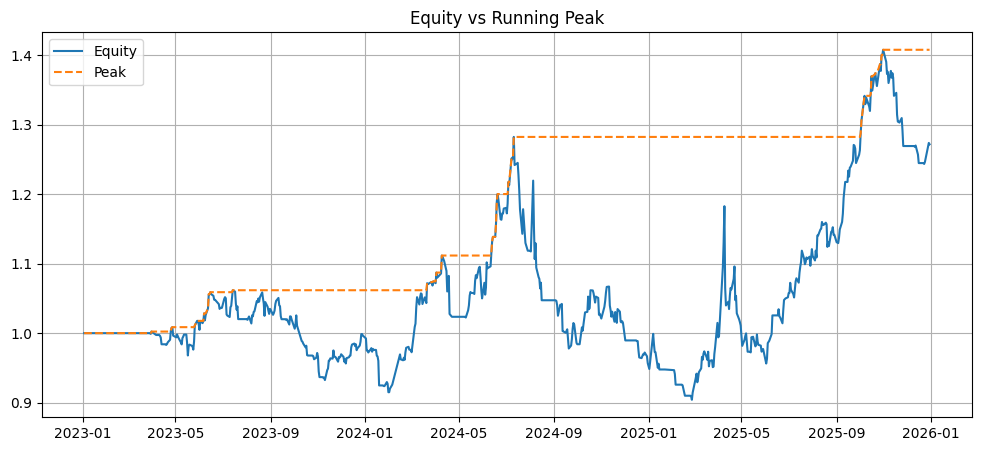

In [20]:
#用同一組最佳參數跑 Test Set

best_test_signal_df = research_strategy(
    test_df,
    ma_short_window=ma_short_window,
    ma_long_window=ma_long_window,
    cci_window=cci_window,
    cci_entry_threshold=best_entry_threshold,
    cci_exit_threshold=best_exit_threshold,
    vol_now_window=vol_now_window,
    atr_window=atr_window,
    atr_mult=atr_mult,
    use_short=use_short,
)

best_test_backtest_df = run_backtest(
    best_test_signal_df,
    fee_rate=fee_rate,
    allow_short=use_short,
)

best_test_metrics, best_test_trade_df, best_test_worst_dd_df = calculate_full_metrics(
    best_test_backtest_df,
    annual_trading_days=252,
    rolling_window=126,
    verbose=True,
    show_plots=True,
)


In [22]:
#整理 Train / Test 比較表

compare_df = pd.DataFrame([
    {
        "dataset": "train",
        "total_return": best_train_metrics["total_return"],
        "cagr": best_train_metrics["cagr"],
        "sharpe": best_train_metrics["sharpe"],
        "mdd": best_train_metrics["mdd"],
        "win_rate": best_train_metrics["win_rate"],
        "profit_factor": best_train_metrics["profit_factor"],
    },
    {
        "dataset": "test",
        "total_return": best_test_metrics["total_return"],
        "cagr": best_test_metrics["cagr"],
        "sharpe": best_test_metrics["sharpe"],
        "mdd": best_test_metrics["mdd"],
        "win_rate": best_test_metrics["win_rate"],
        "profit_factor": best_test_metrics["profit_factor"],
    }
])

print("=== Train vs Test Comparison ===")
display(compare_df)

=== Train vs Test Comparison ===


,dataset,total_return,cagr,sharpe,mdd,win_rate,profit_factor
0,train,0.434362,0.054696,0.405782,-0.256086,0.588235,8.163995
1,test,0.271938,0.087455,0.518499,-0.295078,0.500000,8.776825


## 參數視覺化

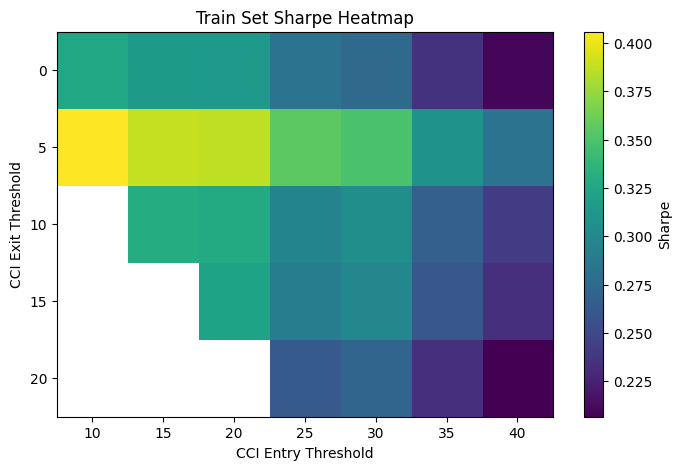

In [23]:
import matplotlib.pyplot as plt

pivot_sharpe = train_result_df.pivot(
    index="cci_exit_threshold",
    columns="cci_entry_threshold",
    values="sharpe"
)

plt.figure(figsize=(8, 5))
plt.imshow(pivot_sharpe, aspect="auto")
plt.colorbar(label="Sharpe")
plt.xticks(range(len(pivot_sharpe.columns)), pivot_sharpe.columns)
plt.yticks(range(len(pivot_sharpe.index)), pivot_sharpe.index)
plt.xlabel("CCI Entry Threshold")
plt.ylabel("CCI Exit Threshold")
plt.title("Train Set Sharpe Heatmap")
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install plotly

In [24]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "notebook_connected"


def plot_3d_surface_slice_interactive(
    train_result_df,
    fixed_filters: dict | None = None,
    x_col="cci_entry_threshold",
    y_col="cci_exit_threshold",
    z_col="sharpe",
    title=None
):
    df = train_result_df.copy()

    # 可選：固定其他參數條件
    if fixed_filters is not None:
        for col, val in fixed_filters.items():
            df = df[df[col] == val]

    if df.empty:
        raise ValueError(f"過濾後沒有資料：{fixed_filters}")

    pivot = df.pivot(
        index=y_col,
        columns=x_col,
        values=z_col
    )

    pivot = pivot.sort_index().sort_index(axis=1)

    x_vals = pivot.columns.values
    y_vals = pivot.index.values
    Z = pivot.values

    if title is None:
        title = f"{z_col} Surface | x={x_col}, y={y_col}"

    fig = go.Figure(
        data=[
            go.Surface(
                x=x_vals,
                y=y_vals,
                z=Z,
                colorscale="Viridis",
                showscale=True
            )
        ]
    )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title=x_col,
            yaxis_title=y_col,
            zaxis_title=z_col,
        ),
        width=950,
        height=700,
    )

    fig.show()

In [25]:
plot_3d_surface_slice_interactive(
    train_result_df,
    x_col="cci_entry_threshold",
    y_col="cci_exit_threshold",
    z_col="sharpe",
    title="CCI Entry / Exit Threshold 3D Sharpe Surface"
)